# Метод 3 — Monte Carlo. Часть 2: β-CatBoost correction

Проблема baseline MC - NB-модель не учитывает, что часть пользователей в кампании может быть менее активна,
эффекты насыщения.
Решение - β-коррекция

  corrected_reach[k] = naive_reach[k] * exp(CatBoost_k(X))

CatBoost обучается на 39-мерных leak-safe агрегатах и предсказывает log-отношение `y / naive`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from dataclasses import dataclass

ROOT = Path('/Users/ensamsanovich/auc_forecast')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'outputs' / 'method_3_monte_carlo'
OUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from catboost import CatBoostRegressor

from core.config import ALPHA, MC_N_SIMS, SEED, TARGETS, set_seed
from core.runner import load_unified_data
from core.leak_safe_features import build_leak_safe_aggregates
from core.metrics import smlar

set_seed()

In [2]:
data = load_unified_data()
val = data['val']
ans = data['ans']
user_index = data['user_index']
pub_index = data['pub_index']
split = data['split']
folds = split['folds']

X = build_leak_safe_aggregates(val, user_index, pub_index)
y = ans[list(TARGETS)].astype(float).values
print(f"X: {X.shape}, y: {y.shape}, folds: {len(folds)}")

X: (1008, 39), y: (1008, 3), folds: 5


In [3]:
def _nb_sample(mu, alpha, size, rng):
    mu = np.asarray(mu, dtype=np.float64)
    alpha = np.asarray(alpha, dtype=np.float64)
    out = np.empty(size, dtype=np.int64)
    poisson_mask = alpha < 1e-6
    if poisson_mask.any():
        out = rng.poisson(np.broadcast_to(mu, size).copy(), size=size)
    if (~poisson_mask).any():
        n = 1.0 / np.where(poisson_mask, 1.0, alpha)
        p = n / (n + mu)
        n = np.broadcast_to(n, size).copy()
        p = np.broadcast_to(p, size).copy()
        out_nb = rng.negative_binomial(n, p, size=size)
        out = np.where(np.broadcast_to(poisson_mask, size), out, out_nb)
    return out

@dataclass
class MCResult:
    reach_samples: np.ndarray
    thresholds: tuple
    @property
    def mean(self):
        return self.reach_samples.mean(axis=0)
    def quantile(self, q):
        return np.quantile(self.reach_samples, q, axis=0)
    def credible_interval(self, alpha=0.10):
        return self.quantile(alpha / 2), self.quantile(1 - alpha / 2)

def simulate_reach(mu, alpha, n_simulations=500, thresholds=(1, 2, 3), seed=42):
    mu = np.asarray(mu, dtype=np.float64).ravel()
    if np.isscalar(alpha):
        alpha = np.full_like(mu, float(alpha))
    else:
        alpha = np.asarray(alpha, dtype=np.float64).ravel()
    n_users = mu.shape[0]
    if n_users == 0:
        return MCResult(np.zeros((n_simulations, len(thresholds))), thresholds)
    rng = np.random.default_rng(seed)
    samples = _nb_sample(mu, alpha, size=(n_simulations, n_users), rng=rng)
    reach = np.stack([(samples >= k).mean(axis=1) for k in thresholds], axis=1)
    return MCResult(reach_samples=reach, thresholds=tuple(thresholds))

def _per_user_rates(user_ids, cutoff_hour, user_index):
    rates = []
    for uid in user_ids:
        feats = user_index.user_features_before(int(uid), cutoff_hour)
        n_imps = feats[0]
        is_cold = feats[4]
        if is_cold == 1.0 or cutoff_hour == 0:
            rates.append(np.nan)
        else:
            rates.append(n_imps / max(cutoff_hour, 1))
    rates = np.array(rates, dtype=np.float64)
    known = rates[~np.isnan(rates)]
    fallback = float(np.mean(known)) if known.size else 0.0
    rates = np.where(np.isnan(rates), fallback, rates)
    return rates

def _build_naive_predictions(val_df, user_index, alpha_disp, n_sims):
    means = np.zeros((len(val_df), 3))
    lows = np.zeros((len(val_df), 3))
    highs = np.zeros((len(val_df), 3))
    for i in range(len(val_df)):
        row = val_df.iloc[i]
        cutoff = int(row['hour_start'])
        duration = int(row['hour_end'] - row['hour_start'])
        rates = _per_user_rates(row['user_ids'], cutoff, user_index)
        mu = np.clip(rates * max(duration, 1), 1e-6, 1e3)
        res = simulate_reach(mu, alpha=alpha_disp, n_simulations=n_sims, seed=SEED + i)
        lo, hi = res.credible_interval(alpha=ALPHA)
        means[i], lows[i], highs[i] = res.mean, lo, hi
    return means, lows, highs

### Предсказания на S = 500 для всех кампаний

In [5]:
ALPHA_DISP = 2.21
S = MC_N_SIMS
naive, naive_lo, naive_hi = _build_naive_predictions(val, user_index, ALPHA_DISP, S)
naive = np.clip(naive, 0.0, 1.0)
print(f"naive.shape = {naive.shape}")
print(f"naive[:3] =\n{naive[:3]}")

naive.shape = (1008, 3)
naive[:3] =
[[0.45219622 0.30921511 0.23591396]
 [0.26891884 0.11242464 0.05532464]
 [0.24256757 0.11977703 0.0717455 ]]


### β-CatBoost коррекция

In [7]:
def fit_beta_correction(naive_train, y_train, X_train):
    models = []
    eps = 1e-6
    for t in range(3):
        log_ratio = np.log((y_train[:, t] + eps) / (naive_train[:, t] + eps))
        m = CatBoostRegressor(iterations=400, depth=4, learning_rate=0.05,
                              random_seed=SEED, verbose=0, allow_writing_files=False)
        m.fit(X_train.values, log_ratio)
        models.append(m)
    return models

def apply_beta(models, naive, X):
    out = np.zeros_like(naive)
    for t, m in enumerate(models):
        out[:, t] = naive[:, t] * np.exp(m.predict(X.values))
    return np.clip(out, 0.0, 1.0)

In [8]:
fold_smlar_naive = []
fold_smlar_corr = []
all_pred_corr = np.zeros_like(naive)

for fold_i, (tr, va) in enumerate(folds, start=1):
    models = fit_beta_correction(naive[tr], y[tr], X.iloc[tr])
    pred_va = apply_beta(models, naive[va], X.iloc[va])
    all_pred_corr[va] = pred_va

    sm_naive = float(smlar(y[va], naive[va]))
    sm_corr = float(smlar(y[va], pred_va))
    fold_smlar_naive.append(sm_naive)
    fold_smlar_corr.append(sm_corr)
    print(f"  fold {fold_i}: SMLAR naive={sm_naive:.2f}%  corrected={sm_corr:.2f}%")

    # PNG: scatter naive vs corrected на target reach@1
    fig, ax = plt.subplots(figsize=(6.5, 6.0))
    ax.scatter(naive[va, 0], pred_va[:, 0], s=18, alpha=0.7, color='steelblue', label='val-точки')
    lim = float(max(naive[va, 0].max(), pred_va[:, 0].max(), 0.05)) * 1.05
    ax.plot([0, lim], [0, lim], color='crimson', ls='--', lw=1.3, label='y = x')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel('Наивный reach@1')
    ax.set_ylabel('Скорректированный reach@1')
    ax.set_title(f"Fold {fold_i}: эффект β-коррекции на reach@1")
    ax.grid(True, ls=':', alpha=0.6)
    ax.legend(loc='upper left')
    out_path = OUT_DIR / f"fig_beta_fold_{fold_i:03d}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=110)
    plt.close()
    print(f"    saved {out_path.name}")

  fold 1: SMLAR naive=409.72%  corrected=29.59%
    saved fig_beta_fold_001.png
  fold 2: SMLAR naive=392.96%  corrected=27.38%
    saved fig_beta_fold_002.png
  fold 3: SMLAR naive=447.91%  corrected=29.06%
    saved fig_beta_fold_003.png
  fold 4: SMLAR naive=310.55%  corrected=28.91%
    saved fig_beta_fold_004.png
  fold 5: SMLAR naive=420.07%  corrected=26.47%
    saved fig_beta_fold_005.png


### SMLAR per fold (naive vs corrected)

  saved fig_smlar_fold_001.png
  saved fig_smlar_fold_002.png
  saved fig_smlar_fold_003.png
  saved fig_smlar_fold_004.png
  saved fig_smlar_fold_005.png


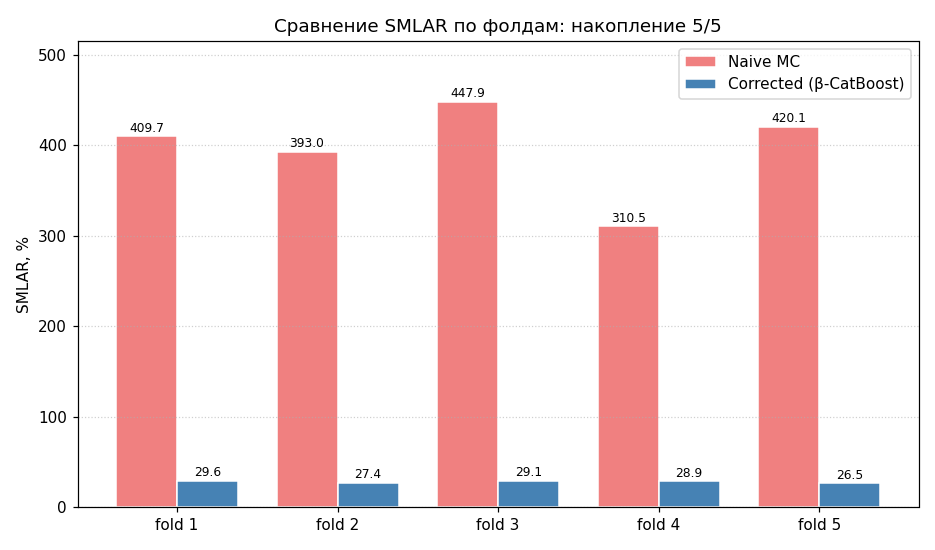

In [9]:
fold_smlar_naive = np.array(fold_smlar_naive)
fold_smlar_corr = np.array(fold_smlar_corr)
y_max_bar = float(np.max(fold_smlar_naive)) * 1.15

for step in range(1, len(folds) + 1):
    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    xs = np.arange(step)
    width = 0.38
    ax.bar(xs - width / 2, fold_smlar_naive[:step], width,
           color='lightcoral', label='Naive MC', edgecolor='white')
    ax.bar(xs + width / 2, fold_smlar_corr[:step], width,
           color='steelblue', label='Corrected (β-CatBoost)', edgecolor='white')
    for i in range(step):
        ax.text(i - width / 2, fold_smlar_naive[i] + y_max_bar * 0.01,
                f"{fold_smlar_naive[i]:.1f}", ha='center', fontsize=8)
        ax.text(i + width / 2, fold_smlar_corr[i] + y_max_bar * 0.01,
                f"{fold_smlar_corr[i]:.1f}", ha='center', fontsize=8)
    ax.set_xticks(xs)
    ax.set_xticklabels([f"fold {i + 1}" for i in range(step)])
    ax.set_ylim(0, y_max_bar)
    ax.set_ylabel('SMLAR, %')
    ax.set_title(f"Сравнение SMLAR по фолдам: накопление {step}/{len(folds)}")
    ax.grid(True, axis='y', ls=':', alpha=0.6)
    ax.legend(loc='upper right')
    out_path = OUT_DIR / f"fig_smlar_fold_{step:03d}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=110)
    plt.close()
    print(f"  saved {out_path.name}")

display(Image(filename=str(OUT_DIR / f"fig_smlar_fold_{len(folds):03d}.png")))

In [11]:
summary = pd.DataFrame({
    'fold': np.arange(1, len(folds) + 1),
    'smlar_naive': fold_smlar_naive,
    'smlar_corrected': fold_smlar_corr,
})
print(summary.to_string(index=False))
print()
print(f"  Naive     CV: {fold_smlar_naive.mean():.2f}% ± {fold_smlar_naive.std():.2f}")
print(f"  Corrected CV: {fold_smlar_corr.mean():.2f}% ± {fold_smlar_corr.std():.2f}")
np.save(OUT_DIR / 'naive_preds.npy', naive)
np.save(OUT_DIR / 'naive_lo.npy', naive_lo)
np.save(OUT_DIR / 'naive_hi.npy', naive_hi)
np.save(OUT_DIR / 'corrected_preds_cv.npy', all_pred_corr)
summary.to_csv(OUT_DIR / 'cv_summary.csv', index=False)

 fold  smlar_naive  smlar_corrected
    1   409.718014        29.594978
    2   392.960587        27.377703
    3   447.912242        29.060833
    4   310.546842        28.908161
    5   420.066977        26.466932

  Naive     CV: 396.24% ± 46.42
  Corrected CV: 28.28% ± 1.17
